Epoch   0 | Loss: 0.3867
Epoch   5 | Loss: 0.2943
Epoch  10 | Loss: 0.2880
Epoch  14 | Loss: 0.2531
cross_entropy: val_acc = 87.40%
Epoch   0 | Loss: 0.1337
Epoch   5 | Loss: 0.1053
Epoch  10 | Loss: 0.0955
Epoch  14 | Loss: 0.1028
squared_error: val_acc = 84.53%


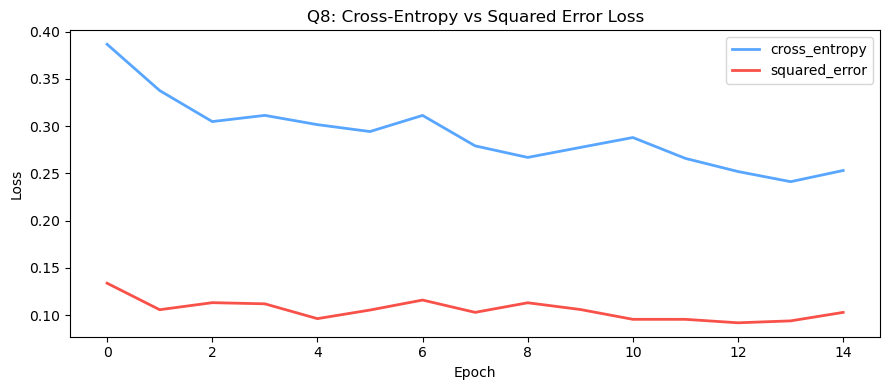

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from neural_network import NeuralNetwork

(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0
val_size = int(0.1 * len(X_train_full))
X_val, y_val = X_train_full[-val_size:], y_train_full[-val_size:]
X_train, y_train = X_train_full[:-val_size], y_train_full[:-val_size]

results = {}
for loss_fn in ['cross_entropy', 'squared_error']:
    m = NeuralNetwork(
        hidden_layers=[128, 128, 128],
        activation='relu',
        weight_init='xavier',
        loss=loss_fn          # <-- your NeuralNetwork already supports this!
    )
    h = m.train(X_train, y_train, epochs=15, learning_rate=1e-3,
                batch_size=64, optimizer='adam', weight_decay=0.0005)
    results[loss_fn] = {
        'loss_curve': h['loss'],
        'val_acc': m.accuracy(X_val, y_val)
    }
    print(f"{loss_fn}: val_acc = {results[loss_fn]['val_acc']*100:.2f}%")

# Plot comparison
fig, ax = plt.subplots(figsize=(9, 4))
for name, color in [('cross_entropy','#58a6ff'), ('squared_error','#f85149')]:
    ax.plot(results[name]['loss_curve'], color=color, linewidth=2, label=name)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Q8: Cross-Entropy vs Squared Error Loss')
ax.legend(); plt.tight_layout()
plt.savefig('q8_loss_comparison.png', dpi=150)
plt.show()